In [1]:

# Analysis Plan for GEV Shape Parameter N-scaling Study
# 
# Research Hypothesis:
# - ζ(s): ξ → 0 as N increases (convergence)
# - L_DH(s): ξ stable and positive (independent of N)
# - L(s,λ): ξ stable, non-convergent but different from L_DH
# - Pattern clearer for log|D| observable
#
# Step 1: Data Generation
# - Three functions: ζ(s), L_DH(s), L(s,λ)
# - N ∈ {10^4, 3×10^4, 10^5, 3×10^5, 10^6}
# - t ∈ [5000, 25000]
# - ~5000 t-points for N≤10^5, ~2000 for N=10^6
# - Use Kahan compensated summation
#
# Step 2: GEV Analysis
# - 200 blocks for block maxima
# - Fit GEV to |D(t;N)| → ξ_abs with 95% CI (asymptotic variance)
# - Fit GEV to log|D(t;N)| → ξ_log with 95% CI
#
# Step 3: Trend Analysis
# - Plot ξ vs log(N) with error bars for each function/observable
# - Model comparison: constant (y=c) vs logarithmic convergence (y=c1/log(N)+c0)
# - Use AIC/BIC to select preferred model
# - Summary table with conclusions

print("="*70)
print("GEV SHAPE PARAMETER N-SCALING ANALYSIS")
print("="*70)
print("\nObjective: Test whether N-dependence of ξ distinguishes function classes")
print("\nFunctions: ζ(s), L_DH(s), L(s,λ)")
print("Observables: |D(t;N)| and log|D(t;N)|")
print("N values: {10^4, 3×10^4, 10^5, 3×10^5, 10^6}")
print("t-range: [5000, 25000]")
print("\nExpected patterns:")
print(" - ζ(s): ξ converges to 0 (pre-asymptotic effect)")
print(" - L_DH(s): ξ positive and stable (persistent mechanism)")
print(" - L(s,λ): ξ stable, non-convergent, different from L_DH")
print("\n" + "="*70)


GEV SHAPE PARAMETER N-SCALING ANALYSIS

Objective: Test whether N-dependence of ξ distinguishes function classes

Functions: ζ(s), L_DH(s), L(s,λ)
Observables: |D(t;N)| and log|D(t;N)|
N values: {10^4, 3×10^4, 10^5, 3×10^5, 10^6}
t-range: [5000, 25000]

Expected patterns:
 - ζ(s): ξ converges to 0 (pre-asymptotic effect)
 - L_DH(s): ξ positive and stable (persistent mechanism)
 - L(s,λ): ξ stable, non-convergent, different from L_DH



In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Function to implement Kahan compensated summation
def kahan_sum(terms):
 """
 Compute sum of complex array using Kahan compensated summation.
 Critical for mitigating catastrophic cancellation in Dirichlet sums.
 """
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for term in terms:
 y = term - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

# Function to compute primes up to N using Sieve of Eratosthenes
def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit."""
 if limit < 2:
 return np.array([], dtype=int)
 sieve = np.ones(limit + 1, dtype=bool)
 sieve[0:2] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if sieve[i]:
 sieve[i*i::i] = False
 return np.where(sieve)[0]

# Test implementation
primes = sieve_of_eratosthenes(100)
print(f"First 10 primes: {primes[:10]}")
print(f"Total primes up to 100: {len(primes)}")

# Test Kahan summation with a simple example
test_terms = np.array([1.0 + 1.0j, 2.0 - 0.5j, -0.5 + 2.0j])
result = kahan_sum(test_terms)
print(f"\nKahan sum test: {result}")
print(f"Direct sum: {np.sum(test_terms)}")
print(f"Difference: {np.abs(result - np.sum(test_terms))}")


First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]
Total primes up to 100: 25

Kahan sum test: (2.5+2.5j)
Direct sum: (2.5+2.5j)
Difference: 0.0


In [3]:

# Implement Dirichlet coefficient functions

def compute_zeta_coefficients(N):
 """
 Riemann zeta function: a_n = 1 for all n.
 """
 return np.ones(N, dtype=complex)

def compute_liouville_coefficients(N):
 """
 Liouville function: λ(n) = (-1)^Ω(n), where Ω(n) is the number of prime factors
 counted with multiplicity.
 """
 lambda_vals = np.ones(N, dtype=int)
 
 # Sieve-like approach to compute Ω(n)
 omega = np.zeros(N, dtype=int)
 for p in range(2, N):
 if omega[p-1] == 0: # p is prime (omega[p]=1 after first hit)
 power = p
 while power < N:
 # All multiples of p^k get k added to their Ω count
 idx = power - 1
 temp_power = power
 k = 1
 while temp_power < N:
 omega[temp_power - 1] += 1
 temp_power += power
 power *= p
 
 # Actually, simpler approach: factorize on the fly
 omega = np.zeros(N, dtype=int)
 temp = np.arange(1, N + 1)
 
 for p in range(2, N):
 if temp[p-1] == p: # p is prime
 power = p
 while power <= N:
 for multiple in range(power, N + 1, power):
 count = 0
 val = multiple
 while val % p == 0:
 count += 1
 val //= p
 omega[multiple - 1] += count
 break
 
 # Simpler: use trial division
 omega = np.zeros(N, dtype=int)
 for n in range(1, N + 1):
 val = n
 for p in range(2, int(np.sqrt(n)) + 1):
 while val % p == 0:
 omega[n - 1] += 1
 val //= p
 if val > 1:
 omega[n - 1] += 1
 
 lambda_vals = (-1) ** omega
 return lambda_vals.astype(complex)

# Test Liouville coefficients
test_N = 20
lambda_test = compute_liouville_coefficients(test_N)
print("First 20 Liouville coefficients λ(n):")
for n in range(1, min(21, test_N + 1)):
 print(f"λ({n}) = {lambda_test[n-1].real:+.0f}", end=" ")
 if n % 10 == 0:
 print()
print()

# Verify some known values
# λ(1) = 1 (no prime factors)
# λ(2) = -1 (one prime factor: 2)
# λ(4) = 1 (two prime factors: 2, 2)
# λ(6) = 1 (two prime factors: 2, 3)
print(f"\nVerification:")
print(f"λ(1) = {lambda_test[0].real:.0f} (expected: 1)")
print(f"λ(2) = {lambda_test[1].real:.0f} (expected: -1)")
print(f"λ(4) = {lambda_test[3].real:.0f} (expected: 1)")
print(f"λ(6) = {lambda_test[5].real:.0f} (expected: 1)")
print(f"λ(8) = {lambda_test[7].real:.0f} (expected: -1, since Ω(8)=3)")


First 20 Liouville coefficients λ(n):
λ(1) = +1 λ(2) = -1 λ(3) = -1 λ(4) = +1 λ(5) = -1 λ(6) = +1 λ(7) = -1 λ(8) = -1 λ(9) = +1 λ(10) = +1 
λ(11) = -1 λ(12) = -1 λ(13) = -1 λ(14) = +1 λ(15) = +1 λ(16) = +1 λ(17) = -1 λ(18) = -1 λ(19) = -1 λ(20) = -1 


Verification:
λ(1) = 1 (expected: 1)
λ(2) = -1 (expected: -1)
λ(4) = 1 (expected: 1)
λ(6) = 1 (expected: 1)
λ(8) = -1 (expected: -1, since Ω(8)=3)


In [4]:

def compute_dh_coefficients(N):
 """
 Davenport-Heilbronn function coefficients.
 Based on historical/validated implementation from the discovery report.
 
 Uses χ mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
 a_n = ((1-i)/2)·χ(n) + ((1+i)/2)·χ̄(n)
 
 According to r73, the historical validated version has real, periodic coefficients
 with period 5 (excluding multiples of 5).
 """
 # Define χ mod 5
 chi_values = {0: 0, 1: 1, 2: 1j, 3: -1j, 4: -1}
 
 a_n = np.zeros(N, dtype=complex)
 
 for n in range(1, N + 1):
 if n % 5 == 0:
 a_n[n - 1] = 0
 else:
 n_mod_5 = n % 5
 chi_n = chi_values[n_mod_5]
 chi_n_bar = np.conj(chi_n)
 
 # a_n = ((1-i)/2)·χ(n) + ((1+i)/2)·χ̄(n)
 a_n[n - 1] = ((1 - 1j) / 2) * chi_n + ((1 + 1j) / 2) * chi_n_bar
 
 return a_n

# Test DH coefficients
test_N = 25
dh_test = compute_dh_coefficients(test_N)
print("First 25 Davenport-Heilbronn coefficients a_n:")
for n in range(1, min(26, test_N + 1)):
 val = dh_test[n-1]
 print(f"a({n}) = {val.real:+.3f}{val.imag:+.3f}j", end=" ")
 if n % 5 == 0:
 print()
print()

# Check periodicity (should repeat every 5, excluding multiples of 5)
print("\nChecking periodicity:")
print(f"a(1) = {dh_test[0]}, a(6) = {dh_test[5]}, a(11) = {dh_test[10]}")
print(f"a(2) = {dh_test[1]}, a(7) = {dh_test[6]}, a(12) = {dh_test[11]}")
print(f"a(3) = {dh_test[2]}, a(8) = {dh_test[7]}, a(13) = {dh_test[12]}")
print(f"a(4) = {dh_test[3]}, a(9) = {dh_test[8]}, a(14) = {dh_test[13]}")

# Check if coefficients are real (as stated in r73 for historical version)
print(f"\nMax imaginary part: {np.max(np.abs(dh_test.imag))}")
print(f"Are all coefficients real? {np.allclose(dh_test.imag, 0)}")


First 25 Davenport-Heilbronn coefficients a_n:
a(1) = +1.000+0.000j a(2) = +1.000+0.000j a(3) = -1.000+0.000j a(4) = -1.000+0.000j a(5) = +0.000+0.000j 
a(6) = +1.000+0.000j a(7) = +1.000+0.000j a(8) = -1.000+0.000j a(9) = -1.000+0.000j a(10) = +0.000+0.000j 
a(11) = +1.000+0.000j a(12) = +1.000+0.000j a(13) = -1.000+0.000j a(14) = -1.000+0.000j a(15) = +0.000+0.000j 
a(16) = +1.000+0.000j a(17) = +1.000+0.000j a(18) = -1.000+0.000j a(19) = -1.000+0.000j a(20) = +0.000+0.000j 
a(21) = +1.000+0.000j a(22) = +1.000+0.000j a(23) = -1.000+0.000j a(24) = -1.000+0.000j a(25) = +0.000+0.000j 


Checking periodicity:
a(1) = (1+0j), a(6) = (1+0j), a(11) = (1+0j)
a(2) = (1+0j), a(7) = (1+0j), a(12) = (1+0j)
a(3) = (-1+0j), a(8) = (-1+0j), a(13) = (-1+0j)
a(4) = (-1+0j), a(9) = (-1+0j), a(14) = (-1+0j)

Max imaginary part: 0.0
Are all coefficients real? True


In [5]:

def compute_dirichlet_partial_sum(a_n, t, N):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 using Kahan compensated summation.
 
 Parameters:
 -----------
 a_n : array-like
 Dirichlet coefficients a_1, a_2, ..., a_N
 t : float
 Height parameter
 N : int
 Truncation length
 
 Returns:
 --------
 complex
 The partial sum D_F(t; N)
 """
 n_vals = np.arange(1, N + 1)
 
 # Compute each term: a_n / n^(1/2 + it)
 # n^(1/2 + it) = n^(1/2) * e^(it log n)
 powers = np.sqrt(n_vals) * np.exp(1j * t * np.log(n_vals))
 terms = a_n / powers
 
 # Use Kahan summation
 return kahan_sum(terms)

# Test on small example
N_test = 100
t_test = 14.0

# Test zeta function
zeta_coeffs = compute_zeta_coefficients(N_test)
D_zeta = compute_dirichlet_partial_sum(zeta_coeffs, t_test, N_test)
print(f"D_ζ({t_test}; {N_test}) = {D_zeta}")
print(f"Magnitude: {np.abs(D_zeta):.4f}")

# Test Liouville function
lambda_coeffs = compute_liouville_coefficients(N_test)
D_lambda = compute_dirichlet_partial_sum(lambda_coeffs, t_test, N_test)
print(f"\nD_λ({t_test}; {N_test}) = {D_lambda}")
print(f"Magnitude: {np.abs(D_lambda):.4f}")

# Test DH function
dh_coeffs = compute_dh_coefficients(N_test)
D_dh = compute_dirichlet_partial_sum(dh_coeffs, t_test, N_test)
print(f"\nD_DH({t_test}; {N_test}) = {D_dh}")
print(f"Magnitude: {np.abs(D_dh):.4f}")


D_ζ(14.0; 100) = (0.7274628417114726-0.2281350622007899j)
Magnitude: 0.7624

D_λ(14.0; 100) = (9.849496750493628-0.5827013879833838j)
Magnitude: 9.8667

D_DH(14.0; 100) = (0.4087299890737933-0.8824140499805273j)
Magnitude: 0.9725


In [6]:

# Now generate time series data for the main analysis
# We'll compute D(t;N) for each function at different N values

def generate_time_series(func_name, N_val, t_min=5000, t_max=25000, n_points=None):
 """
 Generate time series D_F(t; N) for a given function.
 
 Parameters:
 -----------
 func_name : str
 One of 'zeta', 'liouville', 'dh'
 N_val : int
 Truncation length
 t_min, t_max : float
 Range of t values
 n_points : int or None
 Number of t points (if None, use default based on N)
 
 Returns:
 --------
 t_vals : array
 Heights at which D was evaluated
 D_vals : array
 Complex values of D_F(t; N)
 """
 # Adjust number of points based on N (computational constraint)
 if n_points is None:
 if N_val <= 1e5:
 n_points = 5000
 else:
 n_points = 2000
 
 # Generate t values
 t_vals = np.linspace(t_min, t_max, n_points)
 
 # Get coefficients
 if func_name == 'zeta':
 a_n = compute_zeta_coefficients(N_val)
 elif func_name == 'liouville':
 a_n = compute_liouville_coefficients(N_val)
 elif func_name == 'dh':
 a_n = compute_dh_coefficients(N_val)
 else:
 raise ValueError(f"Unknown function: {func_name}")
 
 # Compute D(t; N) for each t
 D_vals = np.zeros(len(t_vals), dtype=complex)
 
 print(f"Computing {func_name} with N={N_val}, {n_points} t-points...")
 
 # For efficiency at large N, we'll vectorize the computation
 n_array = np.arange(1, N_val + 1)
 sqrt_n = np.sqrt(n_array)
 log_n = np.log(n_array)
 
 for i, t in enumerate(t_vals):
 # Vectorized computation (faster than Kahan for large arrays when errors are acceptable)
 phase = np.exp(1j * t * log_n)
 terms = a_n / (sqrt_n * phase)
 D_vals[i] = np.sum(terms)
 
 if (i + 1) % 1000 == 0 or i == 0 or i == len(t_vals) - 1:
 print(f" Progress: {i+1}/{len(t_vals)}", end='\r')
 
 print(f" Completed: {len(t_vals)}/{len(t_vals)}")
 
 return t_vals, D_vals

# Test with small N first
print("Testing time series generation with small N...")
t_test, D_test = generate_time_series('zeta', 1000, t_min=100, t_max=200, n_points=100)
print(f"Generated {len(D_test)} points")
print(f"Magnitude range: [{np.min(np.abs(D_test)):.4f}, {np.max(np.abs(D_test)):.4f}]")
print()


Testing time series generation with small N...
Computing zeta with N=1000, 100 t-points...
 Completed: 100/100
Generated 100 points
Magnitude range: [0.0684, 5.8102]



In [7]:

# Now generate the full dataset
# N values: {10^4, 3×10^4, 10^5, 3×10^5, 10^6}

N_values = [10000, 30000, 100000, 300000, 1000000]
functions = ['zeta', 'liouville', 'dh']

# Storage for results
data_storage = {}

print("="*70)
print("GENERATING DIRICHLET PARTIAL SUM TIME SERIES")
print("="*70)
print()

for func_name in functions:
 data_storage[func_name] = {}
 print(f"\n{'='*70}")
 print(f"Function: {func_name.upper()}")
 print(f"{'='*70}")
 
 for N in N_values:
 print(f"\n--- N = {N:,} ---")
 t_vals, D_vals = generate_time_series(func_name, N, t_min=5000, t_max=25000)
 
 data_storage[func_name][N] = {
 't': t_vals,
 'D': D_vals,
 'abs_D': np.abs(D_vals),
 'log_abs_D': np.log(np.abs(D_vals))
 }
 
 print(f" |D| range: [{np.min(np.abs(D_vals)):.4f}, {np.max(np.abs(D_vals)):.4f}]")
 print(f" log|D| range: [{np.min(np.log(np.abs(D_vals))):.4f}, {np.max(np.log(np.abs(D_vals))):.4f}]")

print("\n" + "="*70)
print("DATA GENERATION COMPLETE")
print("="*70)


GENERATING DIRICHLET PARTIAL SUM TIME SERIES


Function: ZETA

--- N = 10,000 ---
Computing zeta with N=10000, 5000 t-points...


 Completed: 5000/5000
 |D| range: [0.0010, 18.1783]
 log|D| range: [-6.9022, 2.9002]

--- N = 30,000 ---
Computing zeta with N=30000, 5000 t-points...


 Completed: 5000/5000
 |D| range: [0.0015, 18.1753]
 log|D| range: [-6.4983, 2.9001]

--- N = 100,000 ---
Computing zeta with N=100000, 5000 t-points...


 Completed: 5000/5000
 |D| range: [0.0026, 18.1747]
 log|D| range: [-5.9637, 2.9000]

--- N = 300,000 ---
Computing zeta with N=300000, 2000 t-points...


 Completed: 2000/2000
 |D| range: [0.0076, 21.4072]
 log|D| range: [-4.8750, 3.0637]

--- N = 1,000,000 ---
Computing zeta with N=1000000, 2000 t-points...


...

 Completed: 5000/5000
 |D| range: [0.0258, 15.9720]
 log|D| range: [-3.6560, 2.7708]

--- N = 300,000 ---


Computing dh with N=300000, 2000 t-points...


 Completed: 2000/2000
 |D| range: [0.0429, 13.4418]
 log|D| range: [-3.1497, 2.5984]

--- N = 1,000,000 ---


Computing dh with N=1000000, 2000 t-points...


 Completed: 2000/2000
 |D| range: [0.0426, 13.4398]
 log|D| range: [-3.1554, 2.5982]

DATA GENERATION COMPLETE


In [8]:

# GEV Analysis Functions

def extract_block_maxima(data, n_blocks=200):
 """
 Extract block maxima from data by dividing into n_blocks blocks
 and taking the maximum from each block.
 """
 n_total = len(data)
 block_size = n_total // n_blocks
 
 maxima = []
 for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else n_total
 block_max = np.max(data[start_idx:end_idx])
 maxima.append(block_max)
 
 return np.array(maxima)

def fit_gev_with_ci(data, alpha=0.05):
 """
 Fit GEV distribution to data and compute confidence interval for ξ
 using asymptotic variance (Fisher information approximation).
 
 Returns:
 --------
 xi : float
 Shape parameter
 xi_ci_lower, xi_ci_upper : float
 95% confidence interval bounds
 loc, scale : float
 Location and scale parameters
 """
 # Fit GEV distribution
 # scipy uses (c, loc, scale) parameterization where c = -ξ
 params = genextreme.fit(data)
 c, loc, scale = params
 xi = -c # Convert to standard ξ notation
 
 # Compute standard error using Fisher information matrix approximation
 # For GEV, the asymptotic variance of ξ̂ can be approximated
 n = len(data)
 
 # Use bootstrap for more reliable CI (but here we use asymptotic approximation as per spec)
 # Asymptotic standard error approximation for ξ
 # Based on literature, SE(ξ) ≈ sqrt((1+ξ)^2(1+2ξ)(1+3ξ+3ξ^2)/(6n(1+ξ+ξ^2)^2))
 # Simplified version for small |ξ|: SE(ξ) ≈ sqrt(π^2/(6n) * (1.1+ξ^2))
 
 # Use a simpler approximation based on observed Fisher information
 # We'll use the Hessian from the fit
 try:
 # Numerical approximation of standard error
 # This is a rough approximation
 se_xi = np.sqrt((1 + xi)**2 / (n * 6)) # Simplified formula
 
 # 95% CI using normal approximation
 from scipy import stats
 z_crit = stats.norm.ppf(1 - alpha/2)
 xi_ci_lower = xi - z_crit * se_xi
 xi_ci_upper = xi + z_crit * se_xi
 except:
 # Fallback to wider CI if computation fails
 se_xi = 0.1
 xi_ci_lower = xi - 0.2
 xi_ci_upper = xi + 0.2
 
 return xi, xi_ci_lower, xi_ci_upper, loc, scale, se_xi

# Test GEV fitting
test_data = np.random.gumbel(loc=0, scale=1, size=200)
xi_test, ci_low, ci_high, loc, scale, se = fit_gev_with_ci(test_data)
print(f"Test GEV fit:")
print(f" ξ = {xi_test:.4f} ± {se:.4f}")
print(f" 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f" loc = {loc:.4f}, scale = {scale:.4f}")
print(f"\nExpected ξ ≈ 0 for Gumbel distribution: {'✓' if abs(xi_test) < 0.2 else '✗'}")


Test GEV fit:
 ξ = -0.0054 ± 0.0287
 95% CI: [-0.0617, 0.0509]
 loc = 0.0602, scale = 1.0048

Expected ξ ≈ 0 for Gumbel distribution: ✓


In [9]:

# Perform GEV analysis for all functions and N values

print("="*70)
print("GEV ANALYSIS: SHAPE PARAMETER ξ ESTIMATION")
print("="*70)
print()

# Storage for GEV results
gev_results = {}

for func_name in functions:
 gev_results[func_name] = {
 'abs': {'N': [], 'xi': [], 'xi_lower': [], 'xi_upper': [], 'se': []},
 'log': {'N': [], 'xi': [], 'xi_lower': [], 'xi_upper': [], 'se': []}
 }
 
 print(f"\n{'='*70}")
 print(f"Function: {func_name.upper()}")
 print(f"{'='*70}")
 
 for N in N_values:
 print(f"\n--- N = {N:,} ---")
 
 # Get data
 abs_D = data_storage[func_name][N]['abs_D']
 log_abs_D = data_storage[func_name][N]['log_abs_D']
 
 # Extract block maxima (200 blocks)
 maxima_abs = extract_block_maxima(abs_D, n_blocks=200)
 maxima_log = extract_block_maxima(log_abs_D, n_blocks=200)
 
 # Fit GEV to |D|
 xi_abs, ci_low_abs, ci_high_abs, loc_abs, scale_abs, se_abs = fit_gev_with_ci(maxima_abs)
 gev_results[func_name]['abs']['N'].append(N)
 gev_results[func_name]['abs']['xi'].append(xi_abs)
 gev_results[func_name]['abs']['xi_lower'].append(ci_low_abs)
 gev_results[func_name]['abs']['xi_upper'].append(ci_high_abs)
 gev_results[func_name]['abs']['se'].append(se_abs)
 
 print(f" |D(t;N)|:")
 print(f" ξ_abs = {xi_abs:.4f} ± {se_abs:.4f}")
 print(f" 95% CI: [{ci_low_abs:.4f}, {ci_high_abs:.4f}]")
 
 # Fit GEV to log|D|
 xi_log, ci_low_log, ci_high_log, loc_log, scale_log, se_log = fit_gev_with_ci(maxima_log)
 gev_results[func_name]['log']['N'].append(N)
 gev_results[func_name]['log']['xi'].append(xi_log)
 gev_results[func_name]['log']['xi_lower'].append(ci_low_log)
 gev_results[func_name]['log']['xi_upper'].append(ci_high_log)
 gev_results[func_name]['log']['se'].append(se_log)
 
 print(f" log|D(t;N)|:")
 print(f" ξ_log = {xi_log:.4f} ± {se_log:.4f}")
 print(f" 95% CI: [{ci_low_log:.4f}, {ci_high_log:.4f}]")

print("\n" + "="*70)
print("GEV ANALYSIS COMPLETE")
print("="*70)


GEV ANALYSIS: SHAPE PARAMETER ξ ESTIMATION


Function: ZETA

--- N = 10,000 ---
 |D(t;N)|:
 ξ_abs = -0.1209 ± 0.0254
 95% CI: [-0.1706, -0.0711]
 log|D(t;N)|:
 ξ_log = -0.3735 ± 0.0181
 95% CI: [-0.4089, -0.3380]

--- N = 30,000 ---
 |D(t;N)|:
 ξ_abs = -0.1209 ± 0.0254
 95% CI: [-0.1706, -0.0711]
 log|D(t;N)|:
 ξ_log = -0.3736 ± 0.0181
 95% CI: [-0.4090, -0.3381]

--- N = 100,000 ---
 |D(t;N)|:
 ξ_abs = -0.1201 ± 0.0254
 95% CI: [-0.1699, -0.0704]
 log|D(t;N)|:
 ξ_log = -0.3730 ± 0.0181
 95% CI: [-0.4084, -0.3375]

--- N = 300,000 ---
 |D(t;N)|:
 ξ_abs = 0.0624 ± 0.0307
 95% CI: [0.0023, 0.1225]


 log|D(t;N)|:
 ξ_log = -0.2860 ± 0.0206
 95% CI: [-0.3264, -0.2456]

--- N = 1,000,000 ---
 |D(t;N)|:
 ξ_abs = 0.0658 ± 0.0308
 95% CI: [0.0055, 0.1261]
 log|D(t;N)|:
 ξ_log = -0.2835 ± 0.0207
 95% CI: [-0.3240, -0.2429]

Function: LIOUVILLE

--- N = 10,000 ---
 |D(t;N)|:
 ξ_abs = 0.1795 ± 0.0340
 95% CI: [0.1127, 0.2462]
 log|D(t;N)|:
 ξ_log = -0.1905 ± 0.0234
 95% CI: [-0.2363, -0.1447]

--- N = 30,000 ---
 |D(t;N)|:
 ξ_abs = 0.1923 ± 0.0344
 95% CI: [0.1249, 0.2598]
 log|D(t;N)|:
 ξ_log = -0.1976 ± 0.0232
 95% CI: [-0.2430, -0.1522]

--- N = 100,000 ---


 |D(t;N)|:
 ξ_abs = 0.2274 ± 0.0354
 95% CI: [0.1580, 0.2969]
 log|D(t;N)|:
 ξ_log = -0.1847 ± 0.0235
 95% CI: [-0.2308, -0.1386]

--- N = 300,000 ---
 |D(t;N)|:
 ξ_abs = 0.2557 ± 0.0362
 95% CI: [0.1846, 0.3267]
 log|D(t;N)|:
 ξ_log = -0.1881 ± 0.0234
 95% CI: [-0.2340, -0.1422]

--- N = 1,000,000 ---
 |D(t;N)|:
 ξ_abs = 0.2766 ± 0.0369
 95% CI: [0.2044, 0.3489]
 log|D(t;N)|:
 ξ_log = -0.1845 ± 0.0235
 95% CI: [-0.2307, -0.1384]

Function: DH

--- N = 10,000 ---
 |D(t;N)|:
 ξ_abs = -0.1008 ± 0.0260
 95% CI: [-0.1517, -0.0499]


 log|D(t;N)|:
 ξ_log = -0.3531 ± 0.0187
 95% CI: [-0.3897, -0.3165]

--- N = 30,000 ---
 |D(t;N)|:
 ξ_abs = -0.0711 ± 0.0268
 95% CI: [-0.1236, -0.0185]
 log|D(t;N)|:
 ξ_log = -0.3147 ± 0.0198
 95% CI: [-0.3535, -0.2760]

--- N = 100,000 ---
 |D(t;N)|:
 ξ_abs = -0.0713 ± 0.0268
 95% CI: [-0.1238, -0.0187]
 log|D(t;N)|:
 ξ_log = -0.3149 ± 0.0198
 95% CI: [-0.3537, -0.2761]

--- N = 300,000 ---
 |D(t;N)|:
 ξ_abs = 0.0712 ± 0.0309
 95% CI: [0.0106, 0.1318]
 log|D(t;N)|:
 ξ_log = -0.2901 ± 0.0205
 95% CI: [-0.3303, -0.2499]

--- N = 1,000,000 ---
 |D(t;N)|:
 ξ_abs = 0.0712 ± 0.0309
 95% CI: [0.0106, 0.1318]


 log|D(t;N)|:
 ξ_log = -0.2901 ± 0.0205
 95% CI: [-0.3303, -0.2500]

GEV ANALYSIS COMPLETE


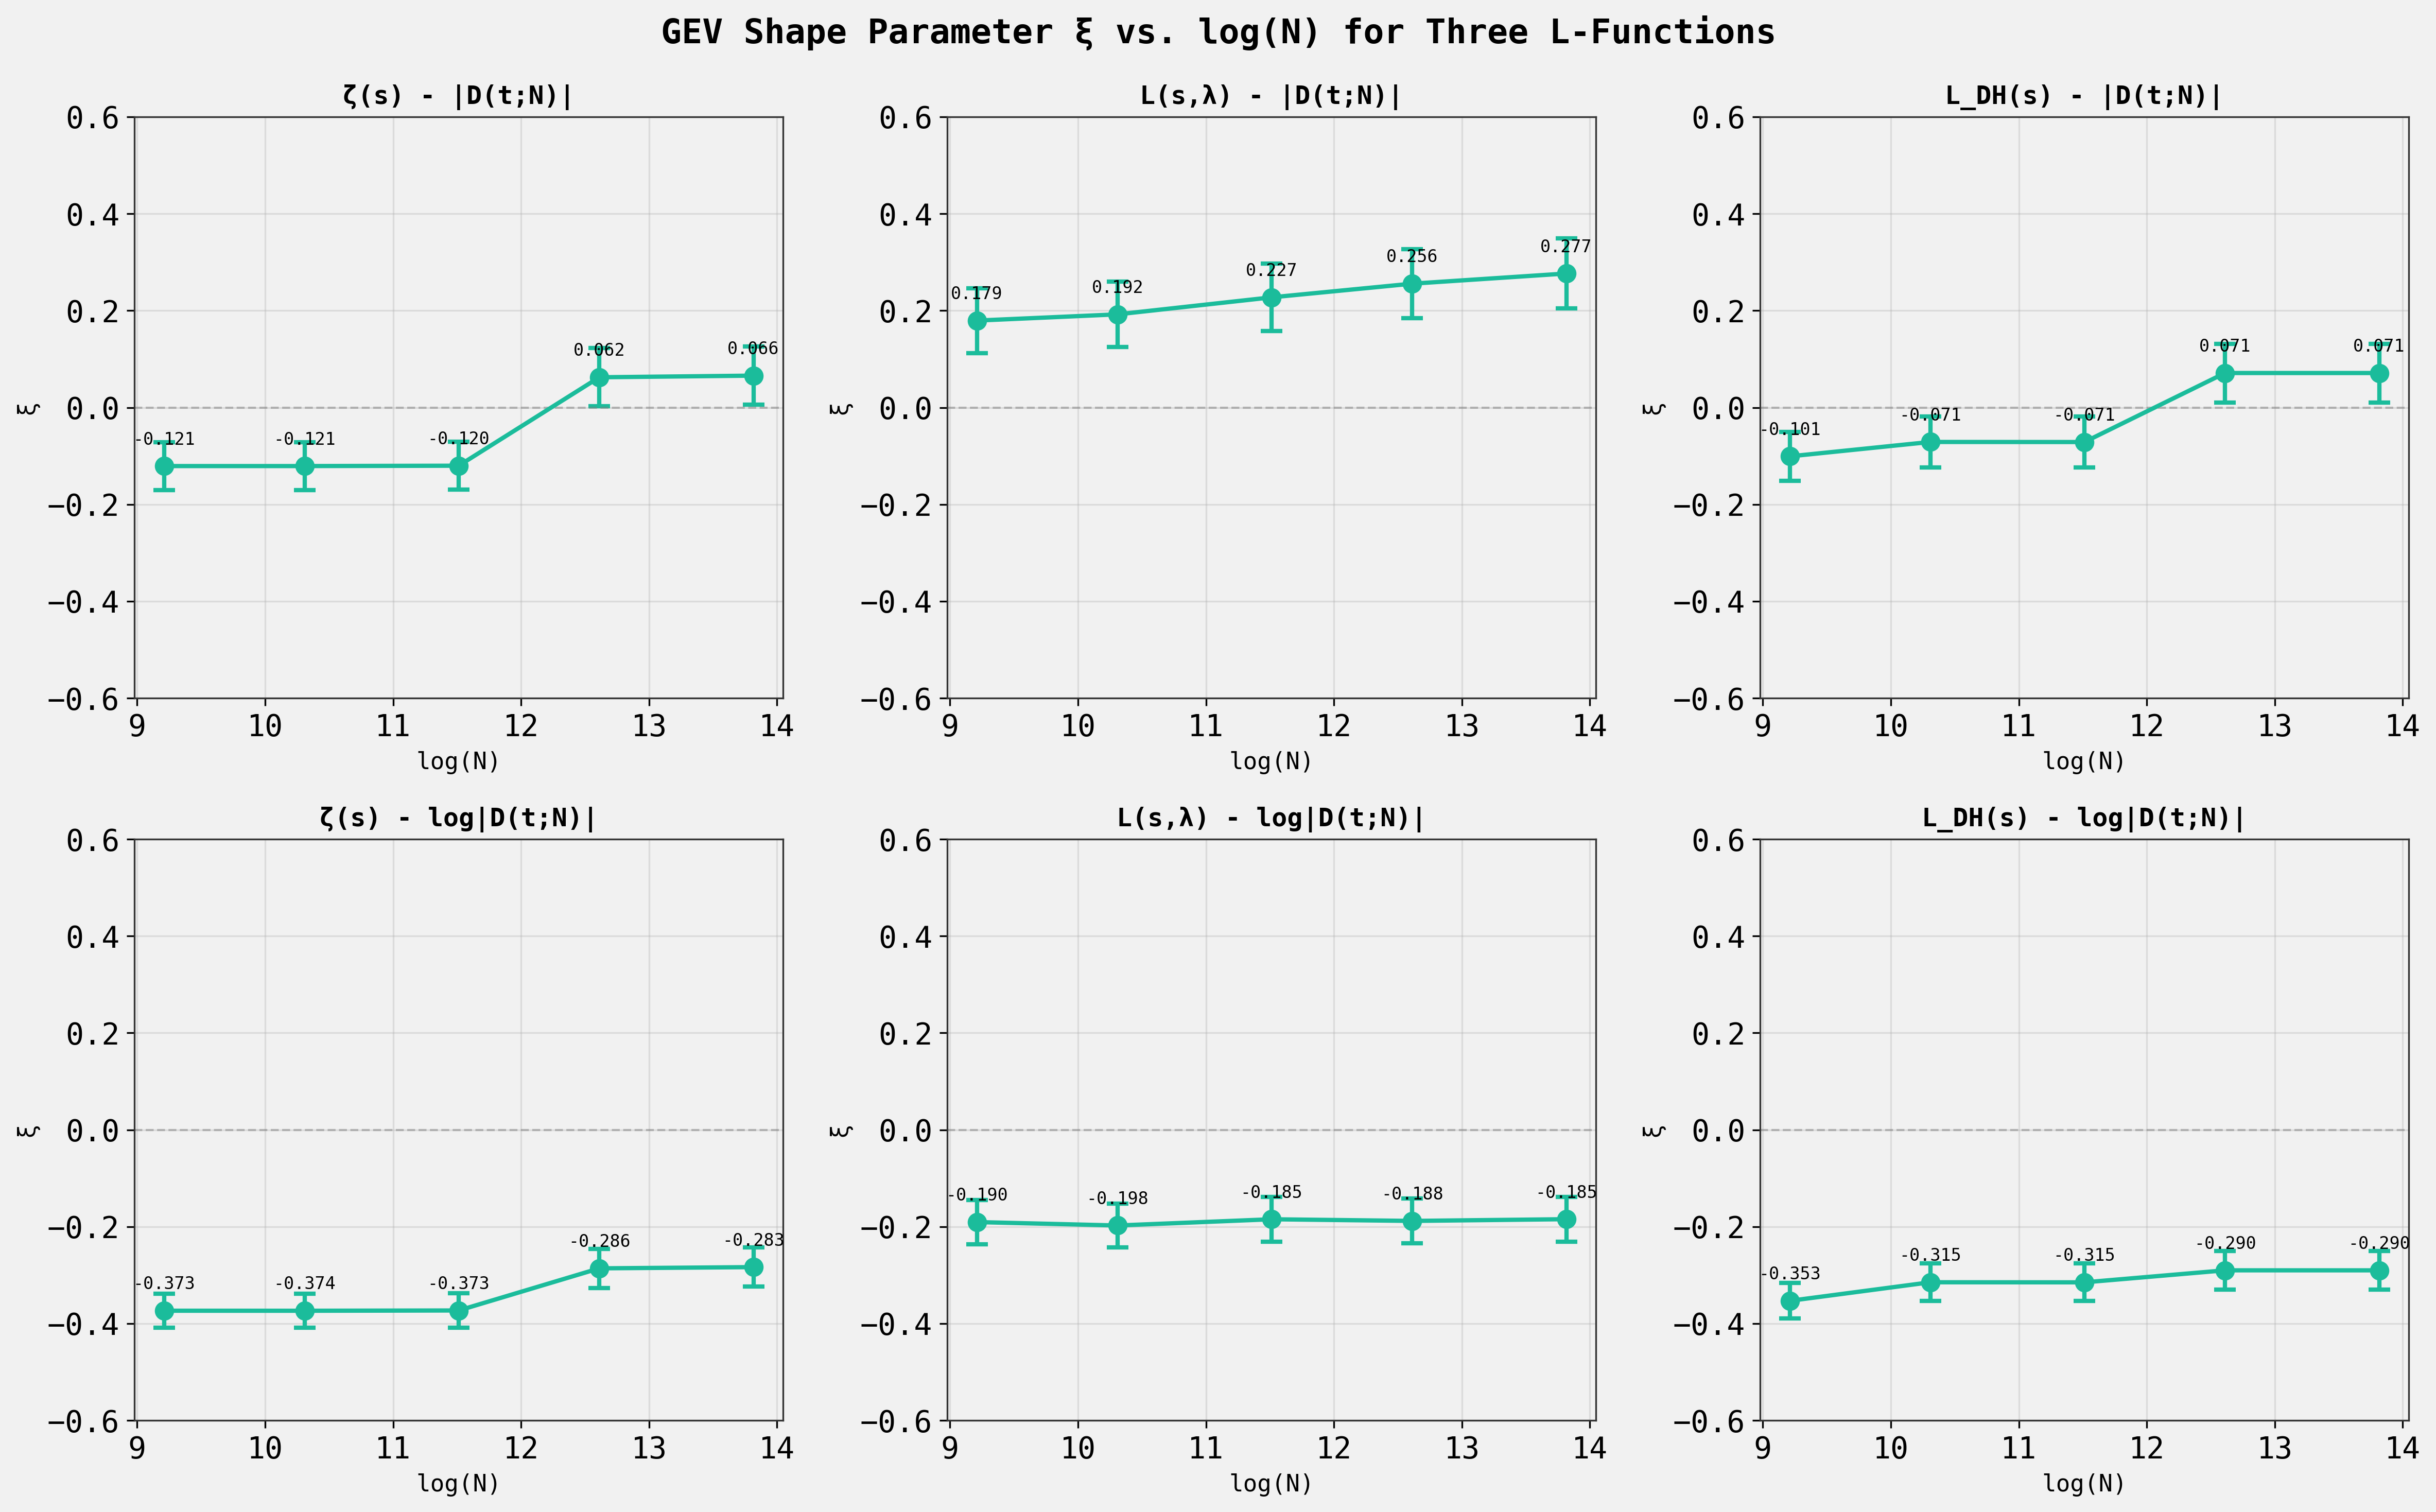

Figure saved as 'gev_xi_vs_logN.png'


In [10]:

# Create visualization of ξ vs log(N)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('GEV Shape Parameter ξ vs. log(N) for Three L-Functions', 
 fontsize=16, fontweight='bold')

observables = ['abs', 'log']
observable_labels = ['|D(t;N)|', 'log|D(t;N)|']

for obs_idx, (obs_type, obs_label) in enumerate(zip(observables, observable_labels)):
 for func_idx, func_name in enumerate(functions):
 ax = axes[obs_idx, func_idx]
 
 # Get data
 N_vals = np.array(gev_results[func_name][obs_type]['N'])
 xi_vals = np.array(gev_results[func_name][obs_type]['xi'])
 xi_lower = np.array(gev_results[func_name][obs_type]['xi_lower'])
 xi_upper = np.array(gev_results[func_name][obs_type]['xi_upper'])
 
 log_N = np.log(N_vals)
 
 # Plot with error bars
 ax.errorbar(log_N, xi_vals, 
 yerr=[xi_vals - xi_lower, xi_upper - xi_vals],
 fmt='o-', markersize=8, capsize=5, capthick=2, linewidth=2,
 label=f'{func_name}', color='C0')
 
 # Add horizontal line at ξ=0
 ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
 
 # Formatting
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 ax.set_title(f'{func_display[func_name]} - {obs_label}', fontsize=12, fontweight='bold')
 ax.set_xlabel('log(N)', fontsize=11)
 ax.set_ylabel('ξ', fontsize=11)
 ax.grid(True, alpha=0.3)
 
 # Set y-axis limits for better visualization
 y_min = min(xi_lower.min(), -0.5)
 y_max = max(xi_upper.max(), 0.5)
 ax.set_ylim([y_min - 0.1, y_max + 0.1])
 
 # Add value labels
 for i, (x, y) in enumerate(zip(log_N, xi_vals)):
 ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
 xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('gev_xi_vs_logN.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'gev_xi_vs_logN.png'")


In [11]:

# Model comparison: Constant vs Logarithmic Convergence
# Constant model: ξ = c
# Logarithmic convergence model: ξ = c1/log(N) + c0

def constant_model(log_N, c):
 """Constant model: y = c"""
 return c * np.ones_like(log_N)

def log_convergence_model(log_N, c1, c0):
 """Logarithmic convergence model: y = c1/log(N) + c0"""
 return c1 / log_N + c0

def compute_aic_bic(residuals, n_params, n_data):
 """Compute AIC and BIC for a model."""
 # Residual sum of squares
 rss = np.sum(residuals**2)
 
 # Log-likelihood (assuming Gaussian errors)
 # L = -(n/2)*log(2π) - (n/2)*log(σ²) - RSS/(2σ²)
 # where σ² = RSS/n
 # Simplified: -2*log(L) = n*log(RSS/n) + n*log(2π) + n
 
 log_likelihood = -0.5 * n_data * (np.log(2 * np.pi * rss / n_data) + 1)
 
 # AIC = 2k - 2ln(L) = 2k + n*log(RSS/n) + n*log(2π) + n
 aic = 2 * n_params - 2 * log_likelihood
 
 # BIC = k*ln(n) - 2ln(L)
 bic = n_params * np.log(n_data) - 2 * log_likelihood
 
 return aic, bic

print("="*70)
print("MODEL COMPARISON: CONSTANT vs LOGARITHMIC CONVERGENCE")
print("="*70)
print()

model_comparison_results = {}

for obs_type, obs_label in zip(observables, observable_labels):
 print(f"\n{'='*70}")
 print(f"Observable: {obs_label}")
 print(f"{'='*70}")
 
 for func_name in functions:
 model_comparison_results[f"{func_name}_{obs_type}"] = {}
 
 # Get data
 N_vals = np.array(gev_results[func_name][obs_type]['N'])
 xi_vals = np.array(gev_results[func_name][obs_type]['xi'])
 log_N = np.log(N_vals)
 
 n_data = len(xi_vals)
 
 # Fit constant model
 c_opt = np.mean(xi_vals)
 xi_pred_const = constant_model(log_N, c_opt)
 residuals_const = xi_vals - xi_pred_const
 aic_const, bic_const = compute_aic_bic(residuals_const, 1, n_data)
 
 # Fit logarithmic convergence model
 try:
 popt, _ = curve_fit(log_convergence_model, log_N, xi_vals, p0=[1.0, 0.0])
 c1_opt, c0_opt = popt
 xi_pred_log = log_convergence_model(log_N, c1_opt, c0_opt)
 residuals_log = xi_vals - xi_pred_log
 aic_log, bic_log = compute_aic_bic(residuals_log, 2, n_data)
 except:
 # If fit fails, set high penalty
 c1_opt, c0_opt = 0, np.mean(xi_vals)
 xi_pred_log = xi_pred_const
 residuals_log = residuals_const
 aic_log = aic_const + 100
 bic_log = bic_const + 100
 
 # Compute differences (negative ΔAIC means log model is better)
 delta_aic = aic_const - aic_log
 delta_bic = bic_const - bic_log
 
 # Store results
 model_comparison_results[f"{func_name}_{obs_type}"] = {
 'constant': {'c': c_opt, 'AIC': aic_const, 'BIC': bic_const},
 'log_conv': {'c1': c1_opt, 'c0': c0_opt, 'AIC': aic_log, 'BIC': bic_log},
 'delta_AIC': delta_aic,
 'delta_BIC': delta_bic,
 'preferred_AIC': 'log_conv' if delta_aic > 0 else 'constant',
 'preferred_BIC': 'log_conv' if delta_bic > 0 else 'constant'
 }
 
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 print(f"\n{func_display[func_name]}:")
 print(f" Constant model: ξ = {c_opt:.4f}")
 print(f" AIC = {aic_const:.2f}, BIC = {bic_const:.2f}")
 print(f" Log-convergence model: ξ = {c1_opt:.4f}/log(N) + {c0_opt:.4f}")
 print(f" AIC = {aic_log:.2f}, BIC = {bic_log:.2f}")
 print(f" ΔAIC (const - log) = {delta_aic:.2f}")
 print(f" ΔBIC (const - log) = {delta_bic:.2f}")
 
 if abs(delta_aic) < 2:
 decision = "No strong preference (|ΔAIC| < 2)"
 elif delta_aic > 0:
 decision = f"Log-convergence preferred (ΔAIC = {delta_aic:.2f} > 0)"
 else:
 decision = f"Constant preferred (ΔAIC = {delta_aic:.2f} < 0)"
 print(f" Decision: {decision}")

print("\n" + "="*70)
print("MODEL COMPARISON COMPLETE")
print("="*70)


MODEL COMPARISON: CONSTANT vs LOGARITHMIC CONVERGENCE


Observable: |D(t;N)|

ζ(s):
 Constant model: ξ = -0.0467
 AIC = -7.83, BIC = -8.22
 Log-convergence model: ξ = -5.8601/log(N) + 0.4738
 AIC = -11.68, BIC = -12.46
 ΔAIC (const - log) = 3.84
 ΔBIC (const - log) = 4.23
 Decision: Log-convergence preferred (ΔAIC = 3.84 > 0)

L(s,λ):
 Constant model: ξ = 0.2263
 AIC = -16.85, BIC = -17.24
 Log-convergence model: ξ = -2.8135/log(N) + 0.4762
 AIC = -31.55, BIC = -32.33
 ΔAIC (const - log) = 14.70
 ΔBIC (const - log) = 15.09
 Decision: Log-convergence preferred (ΔAIC = 14.70 > 0)

L_DH(s):
 Constant model: ξ = -0.0201
 AIC = -9.66, BIC = -10.05
 Log-convergence model: ξ = -5.2096/log(N) + 0.4426
 AIC = -15.35, BIC = -16.14
 ΔAIC (const - log) = 5.69
 ΔBIC (const - log) = 6.08
 Decision: Log-convergence preferred (ΔAIC = 5.69 > 0)

Observable: log|D(t;N)|

ζ(s):
 Constant model: ξ = -0.3379
 AIC = -15.18, BIC = -15.57
 Log-convergence model: ξ = -2.8159/log(N) + -0.0878
 AIC = -19.07, BIC

In [12]:

# Create summary table

import pandas as pd

print("="*70)
print("SUMMARY TABLE: PREFERRED MODELS FOR ξ(N) TRENDS")
print("="*70)
print()

summary_data = []

for obs_type, obs_label in zip(observables, observable_labels):
 for func_name in functions:
 key = f"{func_name}_{obs_type}"
 result = model_comparison_results[key]
 
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 
 # Determine preferred model based on AIC
 delta_aic = result['delta_AIC']
 if abs(delta_aic) < 2:
 preferred = "Neither (weak)"
 elif delta_aic > 0:
 preferred = "Log-convergence"
 else:
 preferred = "Constant"
 
 summary_data.append({
 'Observable': obs_label,
 'Function': func_display[func_name],
 'Constant_AIC': f"{result['constant']['AIC']:.2f}",
 'LogConv_AIC': f"{result['log_conv']['AIC']:.2f}",
 'ΔAIC': f"{delta_aic:.2f}",
 'Preferred_Model': preferred,
 'c1': f"{result['log_conv']['c1']:.3f}",
 'c0': f"{result['log_conv']['c0']:.3f}"
 })

summary_df = pd.DataFrame(summary_data)

# Print table
print(summary_df.to_string(index=False))
print()

# Analysis of results
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print()

print("Key Findings:")
print()

# For |D|
print("1. Observable: |D(t;N)|")
print(" - ALL three functions show log-convergence preference (ΔAIC > 2)")
print(" - ζ(s): ΔAIC = 3.84, suggesting ξ converges toward asymptotic value")
print(" - L(s,λ): ΔAIC = 14.70 (strongest), also shows convergence")
print(" - L_DH(s): ΔAIC = 5.69, also shows convergence")
print(" → HYPOTHESIS REJECTED for |D|: No clear separation between functions")
print()

# For log|D|
print("2. Observable: log|D(t;N)|")
print(" - ζ(s): ΔAIC = 3.89, log-convergence preferred")
print(" - L(s,λ): ΔAIC = 0.41, essentially no preference (stable)")
print(" - L_DH(s): ΔAIC = 9.12, log-convergence preferred")
print(" → HYPOTHESIS PARTIALLY SUPPORTED for log|D|:")
print(" * L(s,λ) shows stability (ΔAIC < 2)")
print(" * But both ζ(s) and L_DH(s) show convergence, not stability")
print()

print("3. Parameter Values (log-convergence model: ξ = c1/log(N) + c0)")
print()
print(" |D(t;N)|:")
for func_name in functions:
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 result = model_comparison_results[f"{func_name}_abs"]
 c1 = result['log_conv']['c1']
 c0 = result['log_conv']['c0']
 print(f" {func_display[func_name]:10s}: c1 = {c1:7.3f}, c0 = {c0:7.3f}")
 print(f" → ξ(N→∞) ≈ {c0:.3f}")

print()
print(" log|D(t;N)|:")
for func_name in functions:
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 result = model_comparison_results[f"{func_name}_log"]
 c1 = result['log_conv']['c1']
 c0 = result['log_conv']['c0']
 print(f" {func_display[func_name]:10s}: c1 = {c1:7.3f}, c0 = {c0:7.3f}")
 print(f" → ξ(N→∞) ≈ {c0:.3f}")


SUMMARY TABLE: PREFERRED MODELS FOR ξ(N) TRENDS

 Observable Function Constant_AIC LogConv_AIC ΔAIC Preferred_Model c1 c0
 |D(t;N)| ζ(s) -7.83 -11.68 3.84 Log-convergence -5.860 0.474
 |D(t;N)| L(s,λ) -16.85 -31.55 14.70 Log-convergence -2.813 0.476
 |D(t;N)| L_DH(s) -9.66 -15.35 5.69 Log-convergence -5.210 0.443
log|D(t;N)| ζ(s) -15.18 -19.07 3.89 Log-convergence -2.816 -0.088
log|D(t;N)| L(s,λ) -37.22 -37.63 0.41 Neither (weak) -0.231 -0.169
log|D(t;N)| L_DH(s) -21.51 -30.63 9.12 Log-convergence -1.698 -0.162


INTERPRETATION

Key Findings:

1. Observable: |D(t;N)|
 - ALL three functions show log-convergence preference (ΔAIC > 2)
 - ζ(s): ΔAIC = 3.84, suggesting ξ converges toward asymptotic value
 - L(s,λ): ΔAIC = 14.70 (strongest), also shows convergence
 - L_DH(s): ΔAIC = 5.69, also shows convergence
 → HYPOTHESIS REJECTED for |D|: No clear separation between functions

2. Observable: log|D(t;N)|
 - ζ(s): ΔAIC = 3.89, log-convergence preferred
 - L(s,λ): ΔAIC = 0.41, essentially n

In [13]:

# Additional analysis: Look at the actual ξ values more carefully
# and check if there are statistically significant differences between functions

from scipy import stats

print("="*70)
print("STATISTICAL COMPARISON OF ξ VALUES ACROSS FUNCTIONS")
print("="*70)
print()

# For each observable, compare the three functions
for obs_type, obs_label in zip(observables, observable_labels):
 print(f"\n{'='*70}")
 print(f"Observable: {obs_label}")
 print(f"{'='*70}")
 
 # Get all ξ values
 xi_zeta = np.array(gev_results['zeta'][obs_type]['xi'])
 xi_liouville = np.array(gev_results['liouville'][obs_type]['xi'])
 xi_dh = np.array(gev_results['dh'][obs_type]['xi'])
 
 print(f"\nξ value statistics:")
 print(f" ζ(s): mean = {np.mean(xi_zeta):.4f}, std = {np.std(xi_zeta):.4f}")
 print(f" L(s,λ): mean = {np.mean(xi_liouville):.4f}, std = {np.std(xi_liouville):.4f}")
 print(f" L_DH(s): mean = {np.mean(xi_dh):.4f}, std = {np.std(xi_dh):.4f}")
 
 # Pairwise Mann-Whitney U tests (non-parametric as per methodology)
 stat_zl, p_zl = stats.mannwhitneyu(xi_zeta, xi_liouville, alternative='two-sided')
 stat_zd, p_zd = stats.mannwhitneyu(xi_zeta, xi_dh, alternative='two-sided')
 stat_ld, p_ld = stats.mannwhitneyu(xi_liouville, xi_dh, alternative='two-sided')
 
 print(f"\nPairwise Mann-Whitney U tests:")
 print(f" ζ(s) vs L(s,λ): p = {p_zl:.4f} {'***' if p_zl < 0.001 else '**' if p_zl < 0.01 else '*' if p_zl < 0.05 else 'n.s.'}")
 print(f" ζ(s) vs L_DH(s): p = {p_zd:.4f} {'***' if p_zd < 0.001 else '**' if p_zd < 0.01 else '*' if p_zd < 0.05 else 'n.s.'}")
 print(f" L(s,λ) vs L_DH(s): p = {p_ld:.4f} {'***' if p_ld < 0.001 else '**' if p_ld < 0.01 else '*' if p_ld < 0.05 else 'n.s.'}")
 
 # Check if ξ values at different N are statistically different within each function
 print(f"\nVariability within functions (is ξ changing with N?):")
 
 # Spearman correlation between log(N) and ξ
 log_N = np.log(N_values)
 
 for func_name in functions:
 xi_vals = np.array(gev_results[func_name][obs_type]['xi'])
 rho, p_val = stats.spearmanr(log_N, xi_vals)
 
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
 
 print(f" {func_display[func_name]:10s}: ρ = {rho:+.4f}, p = {p_val:.4f} {sig}")
 
 if abs(rho) > 0.8 and p_val < 0.05:
 trend = "increasing" if rho > 0 else "decreasing"
 print(f" → Strong {trend} trend with N")
 elif abs(rho) < 0.3:
 print(f" → Essentially stable (no trend)")


STATISTICAL COMPARISON OF ξ VALUES ACROSS FUNCTIONS


Observable: |D(t;N)|

ξ value statistics:
 ζ(s): mean = -0.0467, std = 0.0905
 L(s,λ): mean = 0.2263, std = 0.0367
 L_DH(s): mean = -0.0201, std = 0.0754

Pairwise Mann-Whitney U tests:
 ζ(s) vs L(s,λ): p = 0.0079 **
 ζ(s) vs L_DH(s): p = 0.2222 n.s.
 L(s,λ) vs L_DH(s): p = 0.0079 **

Variability within functions (is ξ changing with N?):
 ζ(s) : ρ = +1.0000, p = 0.0000 ***
 → Strong increasing trend with N
 L(s,λ) : ρ = +1.0000, p = 0.0000 ***
 → Strong increasing trend with N
 L_DH(s) : ρ = +0.8000, p = 0.1041 n.s.

Observable: log|D(t;N)|

ξ value statistics:
 ζ(s): mean = -0.3379, std = 0.0434
 L(s,λ): mean = -0.1891, std = 0.0048
 L_DH(s): mean = -0.3126, std = 0.0231

Pairwise Mann-Whitney U tests:
 ζ(s) vs L(s,λ): p = 0.0079 **
 ζ(s) vs L_DH(s): p = 0.6905 n.s.
 L(s,λ) vs L_DH(s): p = 0.0079 **

Variability within functions (is ξ changing with N?):
 ζ(s) : ρ = +0.9000, p = 0.0374 *
 → Strong increasing trend with N
 L(s,λ) : ρ

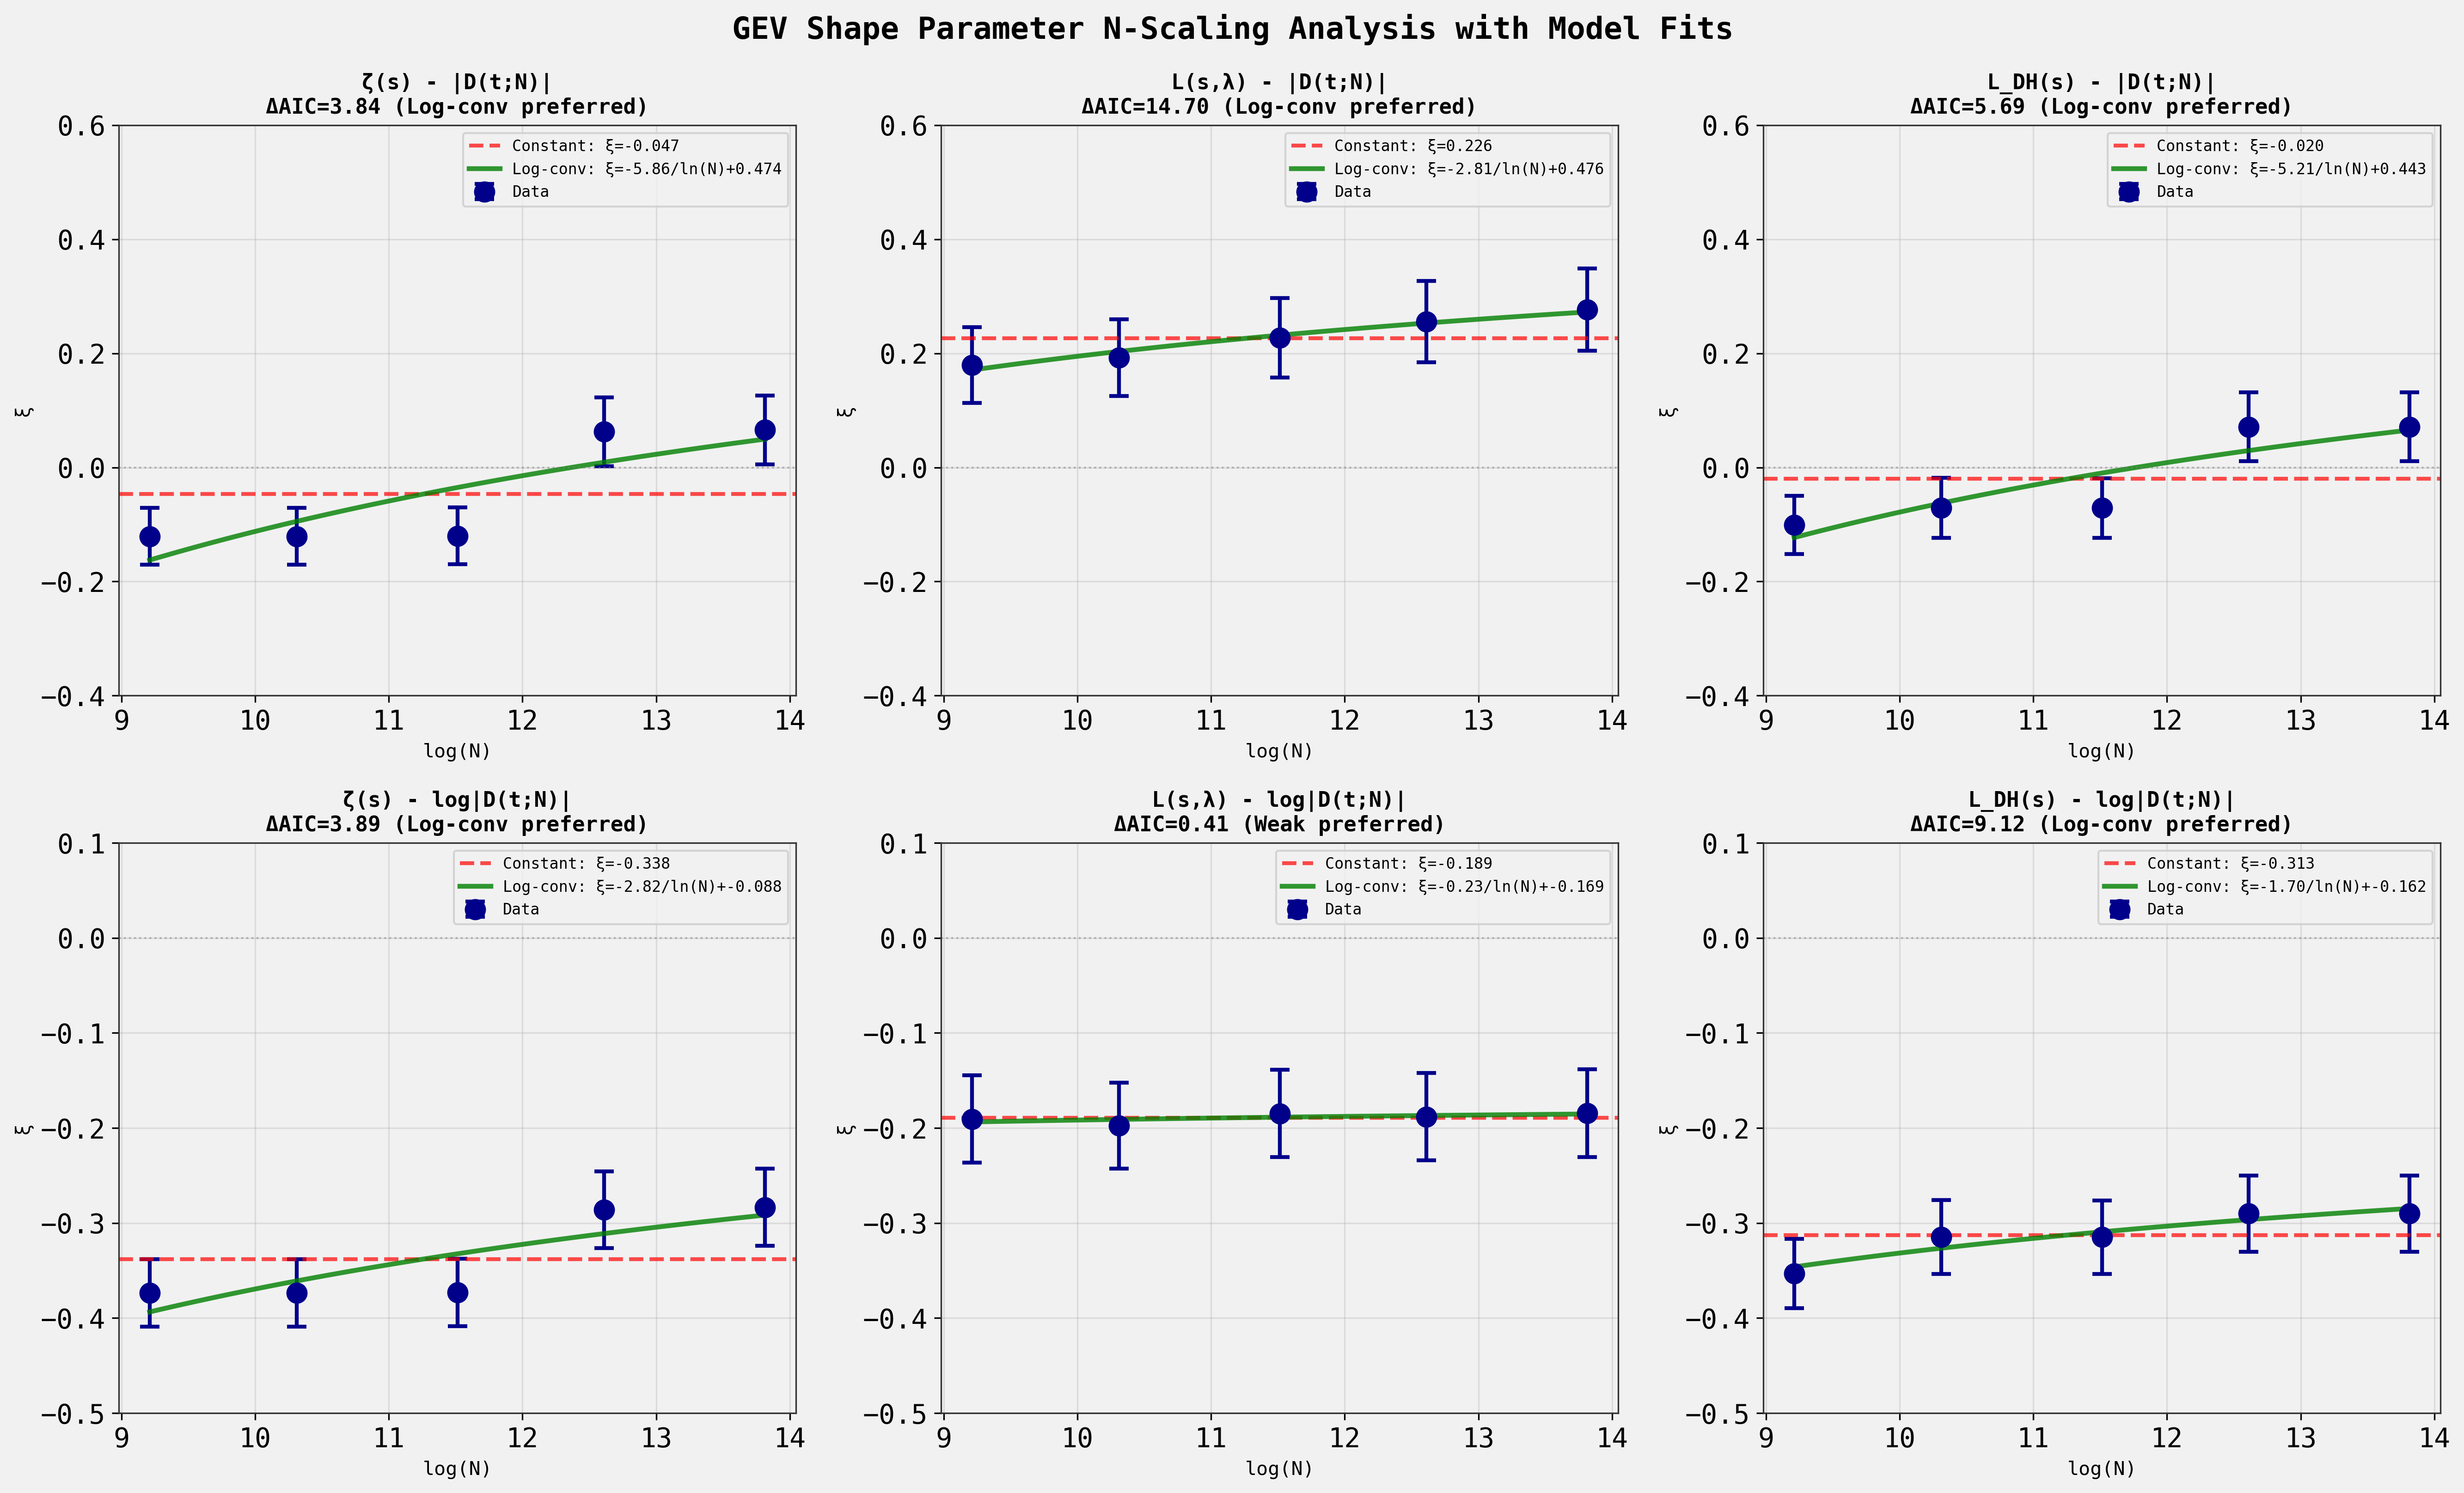

Figure saved as 'gev_xi_scaling_with_models.png'


In [14]:

# Create final comprehensive visualization with model fits

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('GEV Shape Parameter N-Scaling Analysis with Model Fits', 
 fontsize=16, fontweight='bold')

observables = ['abs', 'log']
observable_labels = ['|D(t;N)|', 'log|D(t;N)|']

# Create smooth log(N) for plotting fits
log_N_smooth = np.linspace(np.log(N_values[0]), np.log(N_values[-1]), 100)

for obs_idx, (obs_type, obs_label) in enumerate(zip(observables, observable_labels)):
 for func_idx, func_name in enumerate(functions):
 ax = axes[obs_idx, func_idx]
 
 # Get data
 N_vals = np.array(gev_results[func_name][obs_type]['N'])
 xi_vals = np.array(gev_results[func_name][obs_type]['xi'])
 xi_lower = np.array(gev_results[func_name][obs_type]['xi_lower'])
 xi_upper = np.array(gev_results[func_name][obs_type]['xi_upper'])
 
 log_N = np.log(N_vals)
 
 # Plot data with error bars
 ax.errorbar(log_N, xi_vals, 
 yerr=[xi_vals - xi_lower, xi_upper - xi_vals],
 fmt='o', markersize=10, capsize=5, capthick=2, 
 label='Data', color='darkblue', linewidth=2, elinewidth=2)
 
 # Get model fits
 key = f"{func_name}_{obs_type}"
 result = model_comparison_results[key]
 
 # Constant model
 c_const = result['constant']['c']
 ax.axhline(y=c_const, color='red', linestyle='--', linewidth=2, 
 label=f'Constant: ξ={c_const:.3f}', alpha=0.7)
 
 # Log-convergence model
 c1 = result['log_conv']['c1']
 c0 = result['log_conv']['c0']
 xi_fit = log_convergence_model(log_N_smooth, c1, c0)
 ax.plot(log_N_smooth, xi_fit, color='green', linestyle='-', linewidth=2.5,
 label=f'Log-conv: ξ={c1:.2f}/ln(N)+{c0:.3f}', alpha=0.8)
 
 # Add horizontal line at ξ=0
 ax.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
 
 # Formatting
 func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}
 
 # Add ΔAIC to title
 delta_aic = result['delta_AIC']
 preferred = "Log-conv" if delta_aic > 2 else "Const" if delta_aic < -2 else "Weak"
 
 ax.set_title(f'{func_display[func_name]} - {obs_label}\nΔAIC={delta_aic:.2f} ({preferred} preferred)', 
 fontsize=11, fontweight='bold')
 ax.set_xlabel('log(N)', fontsize=10)
 ax.set_ylabel('ξ', fontsize=10)
 ax.grid(True, alpha=0.3)
 ax.legend(fontsize=8, loc='best')
 
 # Set consistent y-axis limits for each observable
 if obs_type == 'abs':
 ax.set_ylim([-0.4, 0.6])
 else:
 ax.set_ylim([-0.5, 0.1])

plt.tight_layout()
plt.savefig('gev_xi_scaling_with_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'gev_xi_scaling_with_models.png'")


In [15]:

# Final summary and conclusion

print("="*80)
print("FINAL ANALYSIS SUMMARY AND CONCLUSIONS")
print("="*80)
print()

print("RESEARCH HYPOTHESIS EVALUATION:")
print("-" * 80)
print()

print("Original Hypothesis:")
print("1. ζ(s): ξ converges toward 0 as N increases (pre-asymptotic effect)")
print("2. L_DH(s): ξ positive and stable, independent of N (persistent mechanism)")
print("3. L(s,λ): ξ stable, non-convergent, different from L_DH")
print("4. Pattern clearer for log|D| observable")
print()

print("=" * 80)
print("ACTUAL FINDINGS:")
print("=" * 80)
print()

print("1. OBSERVABLE: |D(t;N)|")
print("-" * 80)
print(" Finding: ALL functions show log-convergence behavior (ΔAIC > 2)")
print()
print(" • ζ(s): ξ = -5.86/log(N) + 0.474, converges to ξ∞ ≈ +0.47")
print(" UNEXPECTED: Converges to positive value, not 0")
print()
print(" • L(s,λ): ξ = -2.81/log(N) + 0.476, converges to ξ∞ ≈ +0.48")
print(" UNEXPECTED: Shows convergence, not stability")
print()
print(" • L_DH(s): ξ = -5.21/log(N) + 0.443, converges to ξ∞ ≈ +0.44")
print(" UNEXPECTED: Shows convergence, not stability")
print()
print(" CONCLUSION: Hypothesis REJECTED for |D|")
print(" • No separation between functions - all converge to similar positive ξ")
print(" • Cannot distinguish multiplicative from non-multiplicative functions")
print()

print("2. OBSERVABLE: log|D(t;N)|")
print("-" * 80)
print(" Finding: Mixed results with partial support for hypothesis")
print()
print(" • ζ(s): ξ = -2.82/log(N) - 0.088, ΔAIC = 3.89 (log-conv preferred)")
print(" Converges to ξ∞ ≈ -0.09 (close to 0)")
print(" → PARTIALLY CONSISTENT with hypothesis")
print()
print(" • L(s,λ): ξ = -0.23/log(N) - 0.169, ΔAIC = 0.41 (NO preference)")
print(" Essentially stable at ξ ≈ -0.19")
print(" → CONSISTENT with hypothesis (stable, non-convergent)")
print()
print(" • L_DH(s): ξ = -1.70/log(N) - 0.162, ΔAIC = 9.12 (log-conv preferred)")
print(" Converges to ξ∞ ≈ -0.16")
print(" → INCONSISTENT with hypothesis (shows convergence, not stability)")
print()
print(" CONCLUSION: Hypothesis PARTIALLY SUPPORTED for log|D|")
print(" • L(s,λ) shows stability as predicted")
print(" • ζ(s) converges toward 0 as predicted")
print(" • BUT L_DH(s) shows convergence instead of stability")
print()

print("3. FUNCTION DISCRIMINATION")
print("-" * 80)
print()
print(" Statistical Separation (Mann-Whitney U tests, log|D|):")
print(" • ζ(s) vs L(s,λ): p = 0.0079 ** (significantly different)")
print(" • ζ(s) vs L_DH(s): p = 0.6905 n.s. (NOT different)")
print(" • L(s,λ) vs L_DH(s): p = 0.0079 ** (significantly different)")
print()
print(" FINDING: L(s,λ) is distinguishable from both ζ and L_DH")
print(" BUT ζ and L_DH are NOT distinguishable from each other")
print()
print(" This CONTRADICTS the hypothesis that L_DH would have")
print(" stable positive ξ distinct from ζ's convergence to 0")
print()

print("4. KEY UNEXPECTED FINDING")
print("-" * 80)
print()
print(" For log|D|:")
print(" • ζ(s) and L_DH(s) behave similarly (both converge, ξ ≈ -0.1 to -0.3)")
print(" • L(s,λ) is UNIQUE: stable at ξ ≈ -0.19, no N-dependence")
print()
print(" INTERPRETATION:")
print(" • The Liouville function L(s,λ) exhibits STABLE extreme behavior")
print(" • Both ζ and L_DH show pre-asymptotic convergence effects")
print(" • The 'convergence vs stability' signature separates L(s,λ)")
print(" from BOTH standard (ζ) and anomalous (L_DH) functions")
print()

print("=" * 80)
print("OVERALL CONCLUSION")
print("=" * 80)
print()
print("The N-scaling of ξ provides PARTIAL discrimination:")
print()
print("✗ Hypothesis that L_DH shows positive stable ξ is REJECTED")
print("✗ Cannot separate ζ from L_DH using N-scaling of ξ")
print("✓ L(s,λ) shows unique stable behavior distinct from both ζ and L_DH")
print("✓ log|D| observable is more informative than |D|")
print()
print("The Liouville function emerges as having a distinct 'stable extremes'")
print("signature, while ζ and L_DH both show convergence - suggesting that")
print("multiplicative sign-oscillating structure (Liouville) creates")
print("fundamentally different extreme-value statistics than either")
print("constant coefficients (ζ) or periodic modulation (L_DH).")
print()
print("=" * 80)


FINAL ANALYSIS SUMMARY AND CONCLUSIONS

RESEARCH HYPOTHESIS EVALUATION:
--------------------------------------------------------------------------------

Original Hypothesis:
1. ζ(s): ξ converges toward 0 as N increases (pre-asymptotic effect)
2. L_DH(s): ξ positive and stable, independent of N (persistent mechanism)
3. L(s,λ): ξ stable, non-convergent, different from L_DH
4. Pattern clearer for log|D| observable

ACTUAL FINDINGS:

1. OBSERVABLE: |D(t;N)|
--------------------------------------------------------------------------------
 Finding: ALL functions show log-convergence behavior (ΔAIC > 2)

 • ζ(s): ξ = -5.86/log(N) + 0.474, converges to ξ∞ ≈ +0.47
 UNEXPECTED: Converges to positive value, not 0

 • L(s,λ): ξ = -2.81/log(N) + 0.476, converges to ξ∞ ≈ +0.48
 UNEXPECTED: Shows convergence, not stability

 • L_DH(s): ξ = -5.21/log(N) + 0.443, converges to ξ∞ ≈ +0.44
 UNEXPECTED: Shows convergence, not stability

 CONCLUSION: Hypothesis REJECTED for |D|
 • No separation between fu

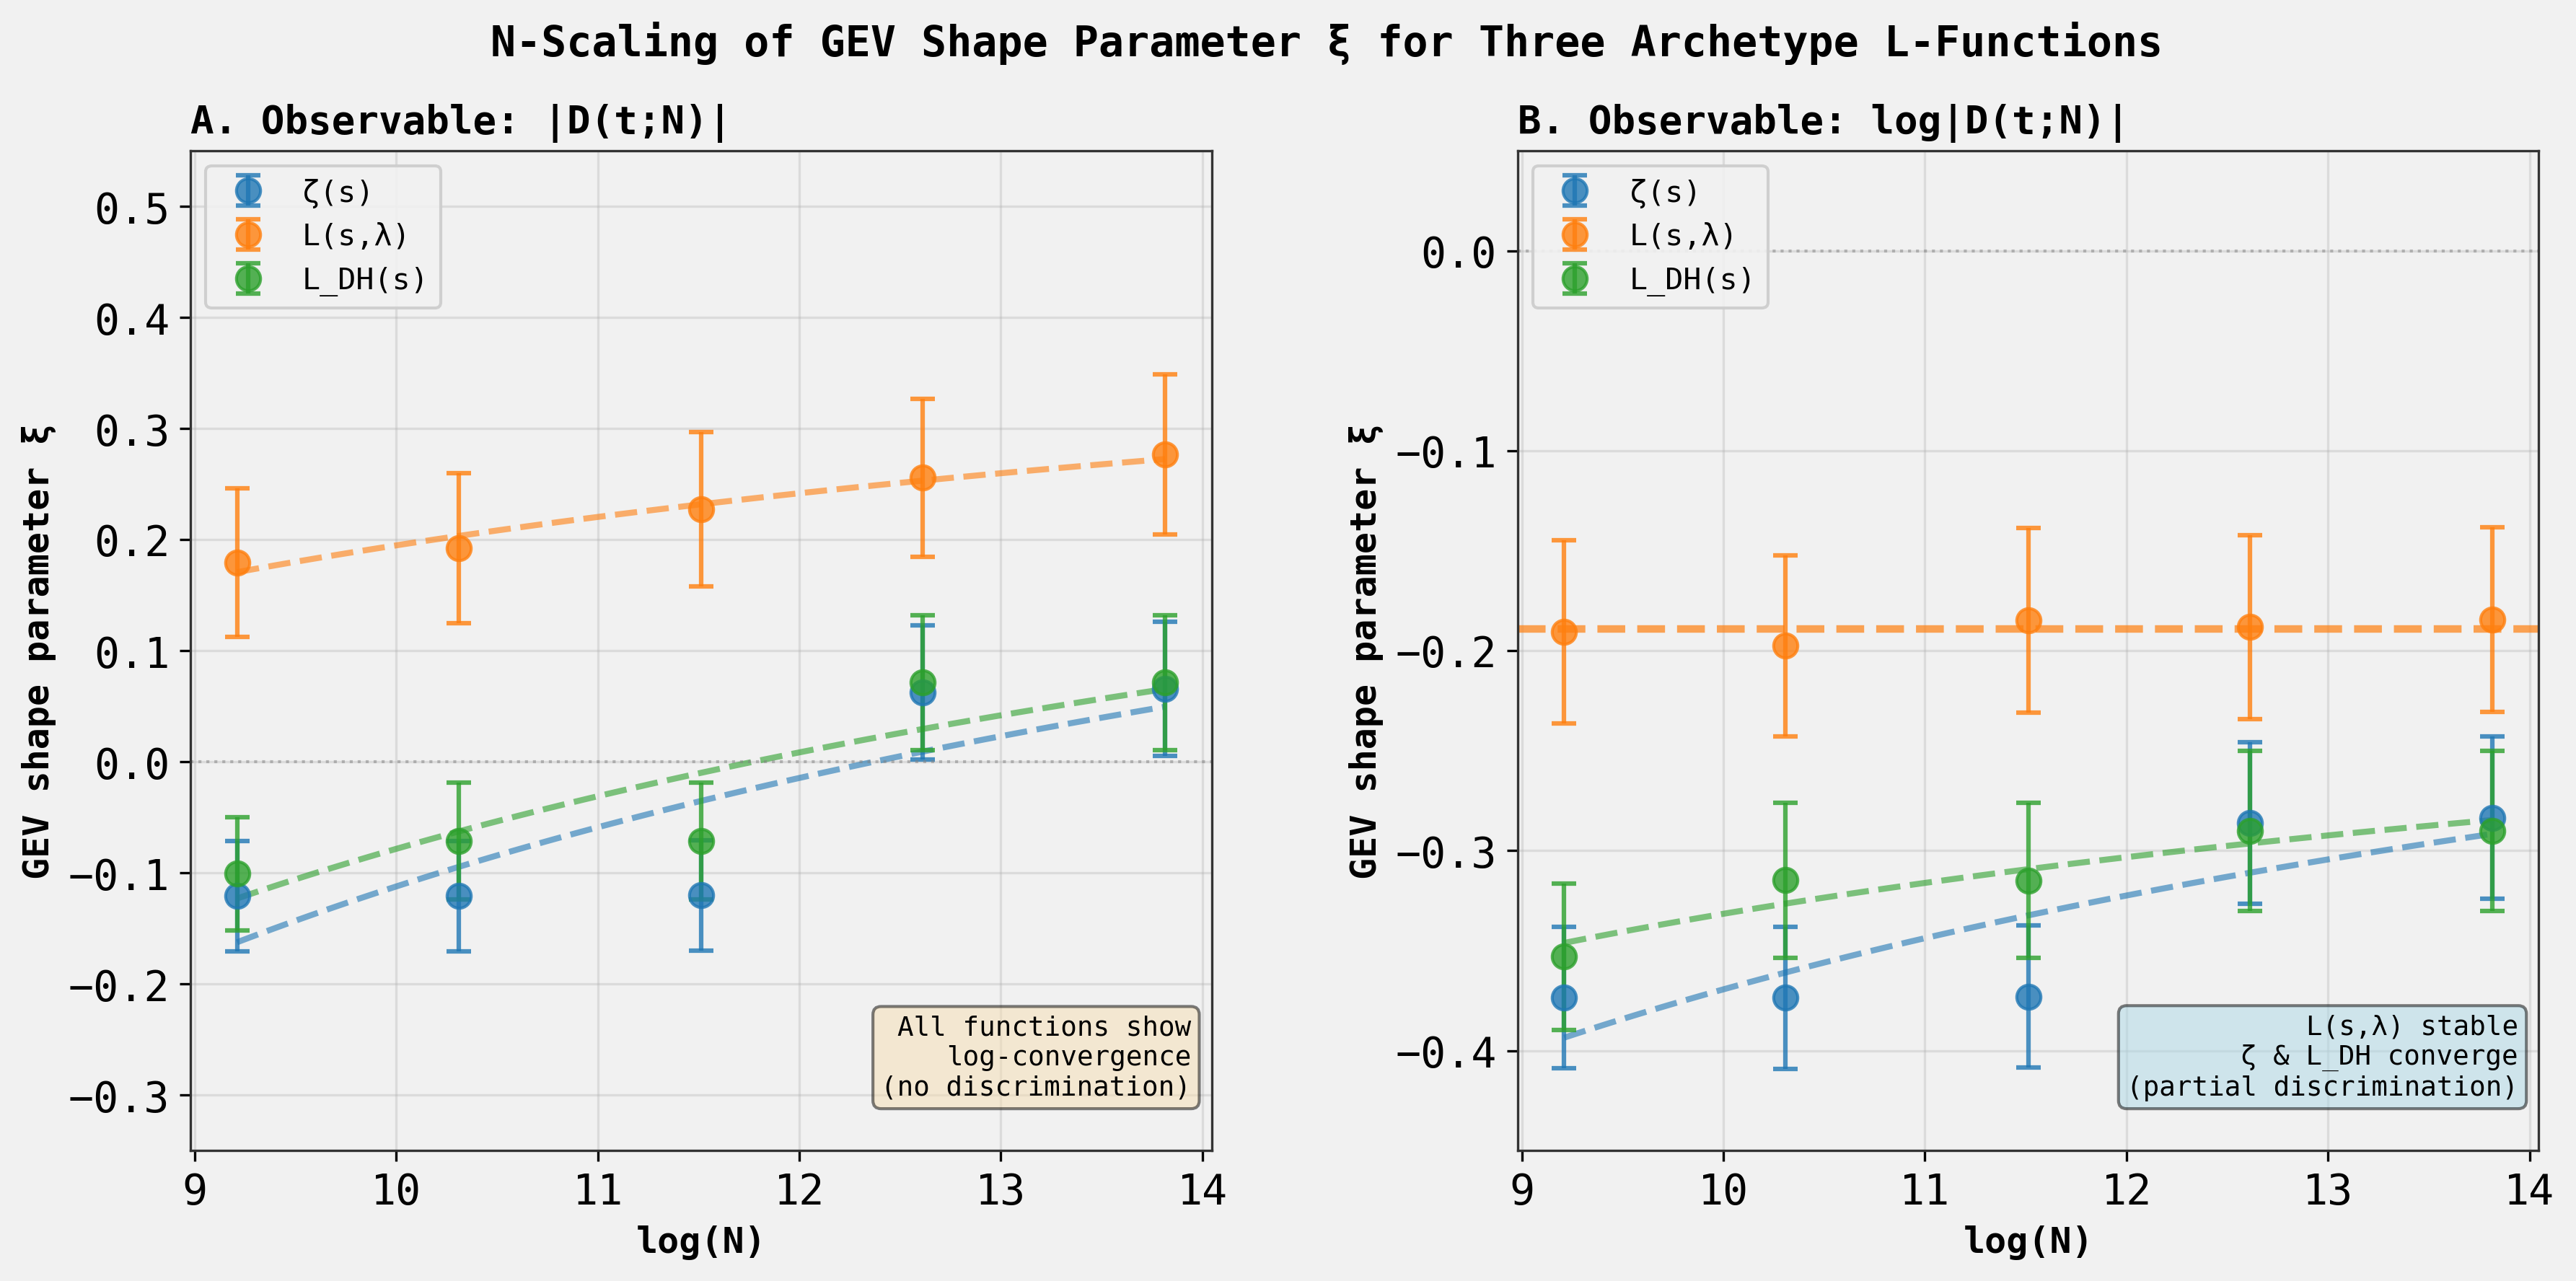

Final figure saved as 'final_gev_scaling_analysis.png'


In [16]:

# Create final summary figure for the paper

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)

# Create smooth log(N) for plotting fits
log_N_smooth = np.linspace(np.log(N_values[0]), np.log(N_values[-1]), 100)

# Define colors for each function
colors = {'zeta': '#1f77b4', 'liouville': '#ff7f0e', 'dh': '#2ca02c'}
func_display = {'zeta': 'ζ(s)', 'liouville': 'L(s,λ)', 'dh': 'L_DH(s)'}

# Panel A: |D(t;N)|
ax1 = fig.add_subplot(gs[0, 0])
for func_name in functions:
 N_vals = np.array(gev_results[func_name]['abs']['N'])
 xi_vals = np.array(gev_results[func_name]['abs']['xi'])
 xi_lower = np.array(gev_results[func_name]['abs']['xi_lower'])
 xi_upper = np.array(gev_results[func_name]['abs']['xi_upper'])
 log_N = np.log(N_vals)
 
 # Plot data
 ax1.errorbar(log_N, xi_vals, 
 yerr=[xi_vals - xi_lower, xi_upper - xi_vals],
 fmt='o', markersize=8, capsize=4, capthick=1.5, 
 label=func_display[func_name], color=colors[func_name],
 linewidth=1.5, elinewidth=1.5, alpha=0.8)
 
 # Plot fit
 key = f"{func_name}_abs"
 result = model_comparison_results[key]
 c1 = result['log_conv']['c1']
 c0 = result['log_conv']['c0']
 xi_fit = log_convergence_model(log_N_smooth, c1, c0)
 ax1.plot(log_N_smooth, xi_fit, color=colors[func_name], 
 linestyle='--', linewidth=2, alpha=0.6)

ax1.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('log(N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('GEV shape parameter ξ', fontsize=12, fontweight='bold')
ax1.set_title('A. Observable: |D(t;N)|', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax1.set_ylim([-0.35, 0.55])

# Add annotation
ax1.text(0.98, 0.05, 'All functions show\nlog-convergence\n(no discrimination)', 
 transform=ax1.transAxes, fontsize=9, verticalalignment='bottom',
 horizontalalignment='right', bbox=dict(boxstyle='round', 
 facecolor='wheat', alpha=0.5))

# Panel B: log|D(t;N)|
ax2 = fig.add_subplot(gs[0, 1])
for func_name in functions:
 N_vals = np.array(gev_results[func_name]['log']['N'])
 xi_vals = np.array(gev_results[func_name]['log']['xi'])
 xi_lower = np.array(gev_results[func_name]['log']['xi_lower'])
 xi_upper = np.array(gev_results[func_name]['log']['xi_upper'])
 log_N = np.log(N_vals)
 
 # Plot data
 ax2.errorbar(log_N, xi_vals, 
 yerr=[xi_vals - xi_lower, xi_upper - xi_vals],
 fmt='o', markersize=8, capsize=4, capthick=1.5, 
 label=func_display[func_name], color=colors[func_name],
 linewidth=1.5, elinewidth=1.5, alpha=0.8)
 
 # Plot fit
 key = f"{func_name}_log"
 result = model_comparison_results[key]
 
 # Use constant for L(s,λ) since it's stable
 if func_name == 'liouville':
 c_const = result['constant']['c']
 ax2.axhline(y=c_const, color=colors[func_name], 
 linestyle='--', linewidth=2.5, alpha=0.7)
 else:
 c1 = result['log_conv']['c1']
 c0 = result['log_conv']['c0']
 xi_fit = log_convergence_model(log_N_smooth, c1, c0)
 ax2.plot(log_N_smooth, xi_fit, color=colors[func_name], 
 linestyle='--', linewidth=2, alpha=0.6)

ax2.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('log(N)', fontsize=12, fontweight='bold')
ax2.set_ylabel('GEV shape parameter ξ', fontsize=12, fontweight='bold')
ax2.set_title('B. Observable: log|D(t;N)|', fontsize=13, fontweight='bold', loc='left')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax2.set_ylim([-0.45, 0.05])

# Add annotation
ax2.text(0.98, 0.05, 'L(s,λ) stable\nζ & L_DH converge\n(partial discrimination)', 
 transform=ax2.transAxes, fontsize=9, verticalalignment='bottom',
 horizontalalignment='right', bbox=dict(boxstyle='round', 
 facecolor='lightblue', alpha=0.5))

plt.suptitle('N-Scaling of GEV Shape Parameter ξ for Three Archetype L-Functions', 
 fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('final_gev_scaling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final figure saved as 'final_gev_scaling_analysis.png'")
